In [1]:
from SmwusNetwork import SmwusNetwork
import matplotlib.pyplot as plt
import numpy as np

my_network = SmwusNetwork(state = 'Rate control')


In [2]:
my_network.run(t = 400, sampling_rate = 100)

In [3]:
import pandas as pd
t = my_network.get_record('time')
W = my_network.get_record('W')
x_bar =  my_network.get_record('x_bar')
x =  my_network.get_record('x')
y =  my_network.get_record('y')
phi =  my_network.get_record('_phi')
phi_post =  my_network.get_record('_phi_post')
phi_pre =  my_network.get_record('_phi_pre')
fluctuation_rate =  my_network.get_record('_fluctuation_rate')

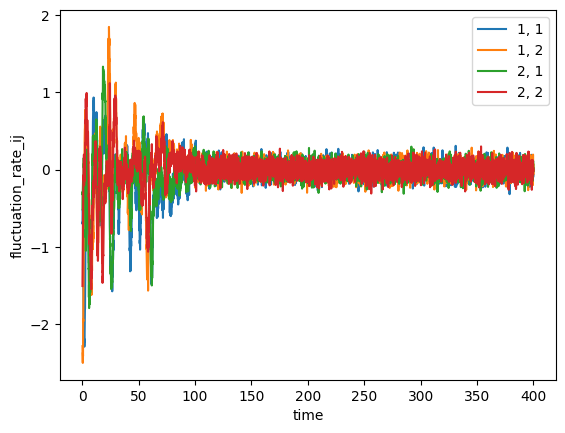

In [4]:
for i in range(2):
    for j in range(2):
        plt.plot(t, fluctuation_rate[:, i, j], label = str(i+1) + ', ' + str(j+1)) 
plt.xlabel('time')
plt.ylabel('fluctuation_rate_ij')
plt.legend()
plt.show()

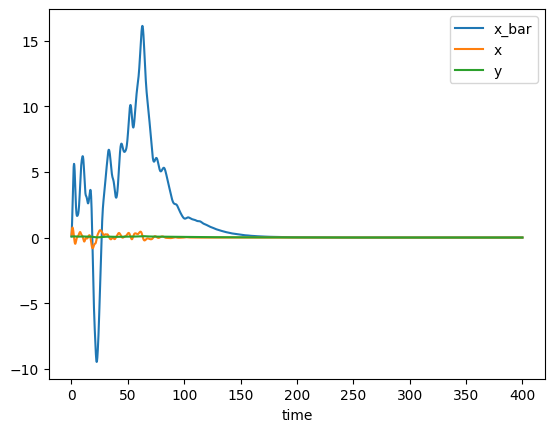

In [5]:
for i in range(1):
    plt.plot(t, x_bar[:, i], label = 'x_bar') 
    plt.plot(t, x[:, i], label = 'x')
    plt.plot(t, y[:, i], label = 'y')
    
plt.xlabel('time')
plt.legend()
plt.show()

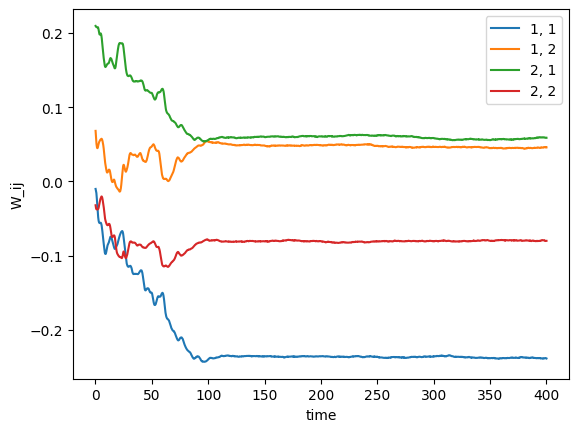

In [6]:
for i in range(2):
    for j in range(2):
        plt.plot(t, W[:, i, j], label = str(i+1) + ', ' + str(j+1)) 
        
plt.xlabel('time')
plt.ylabel('W_ij')
plt.legend()
plt.show()

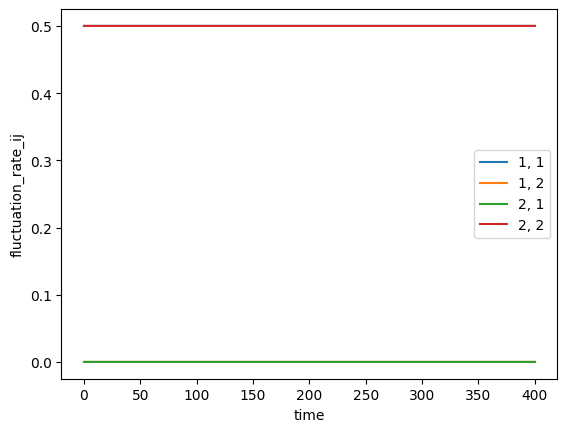

In [7]:
for i in range(2):
    for j in range(2):
        plt.plot(t, 0.5*np.diag(np.ones(128))[i, j] - phi_post[:, i, 0]* phi_pre[:, j, 0], label = str(i+1) + ', ' + str(j+1)) 
    

plt.xlabel('time')
plt.ylabel('fluctuation_rate_ij')
plt.legend()
plt.show()

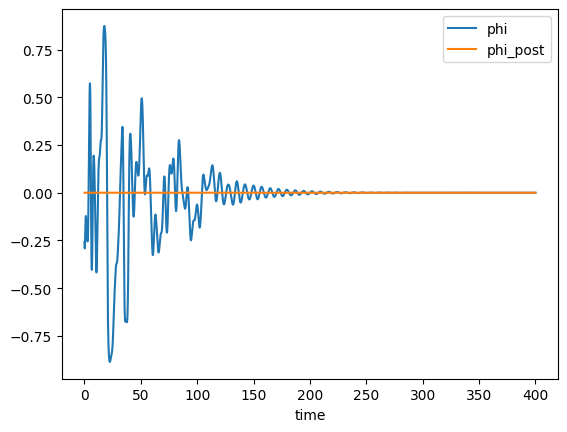

In [14]:
for i in range(1):
    plt.plot(t[:], phi[:, i], label = 'phi') 
    plt.plot(t[:], phi_post[:, i], label = 'phi_post')
    # plt.plot(t, phi_pre[:, i], label = 'phi_pre')
    
plt.xlabel('time')
plt.legend()
plt.show()

In [44]:
phi_post.shape

(2000, 128, 1)

In [ ]:
np.arange(4).reshape([2, 2])*np.arange(4).reshape([2, 2])

In [89]:
from eigenshuffle import eigenshuffle

eigenshuffle()

(2000, 128, 128)

In [8]:
import numpy as np
from numpy.random import randn
from numpy import sqrt, transpose, zeros, sign

N = 128
dt = 0.1
etaS = 0.01
g = 1.0
tau = 20
tauy = 100
Nmem = 2


TotalSteps = int(3000/dt - 1)
CalcEvery = int(10/dt)
Nsteps = int((TotalSteps + 1)/CalcEvery)

x = randn(N, 1)
x_all = zeros([N, TotalSteps])
xlp = randn()
W_all = zeros([N, N, Nsteps])
hs_all = zeros([N, N, Nsteps])
noise_all = zeros([N, N, Nsteps])
W = 2*randn(N, N)/sqrt(N)
r0 = 2*(randn(N, 1) - 0.5)
zeta = 0.01
y = randn(N, 1)

H = sign(randn(N, N)/sqrt(N))
u = transpose(H[0:Nmem, :])/sqrt(N)
v = transpose(H[Nmem:2*Nmem, :])/sqrt(N)
input1 = zeros([N, TotalSteps])
input2 = zeros([N, TotalSteps])

base = int(500/dt)
inLen = int(100/dt)
input = np.zeros([N, 1])

# Construct input signal for learning
for i in range(Nmem):
    input1[:, base: base + inLen] = np.tile(u[:, i].reshape([N, 1]), [1, inLen])
    input2[:, base: base + inLen] = np.tile(v[:, i].reshape([N, 1]), [1, inLen])

# evolve network
for i in range(TotalSteps):
    x_all[:, i] = np.squeeze(x)
    r = np.tanh(g*x)
    xlp = ((-xlp + x/0.05)/tau)*dt
    y = y + (r-y)*dt/tauy
    input = input + (-zeta*input + randn()*input1[:, i].reshape([N, 1]) + randn()*input2[:, i].reshape([N, 1]))

    x = x + (-x + np.matmul(W, r) + 10*input)*dt
    L = np.matmul(r, transpose(y)) - np.matmul(y, transpose(r))
    hs = np.matmul(np.matmul((r0 - r), transpose(r)) , W)
    
    noise = (1*randn(N, N))/sqrt(N)
    W = W + etaS*(noise + hs + L)*dt
    
    if np.mod(i, CalcEvery) == 0:
        W_all[:, :, int(i/CalcEvery)] = W
        
        

/var/folders/wg/0phn_xdj13l7g8nh_5cwybn00000gp/T/ipykernel_33427/2752923225.py:52: RuntimeWarning: invalid value encountered in matmul
  x = x + (-x + np.matmul(W, r) + 10*input)*dt
